# Phân tích rủi ro khoản vay ngân hàng Ấn Độ

Notebook này sử dụng dữ liệu đã làm sạch để đánh giá tương quan, phân phối và đặc điểm của nhóm khách hàng có `Risk Flag = 1`.


## 1. Khai báo thư viện, đường dẫn và cấu hình chung

Các biểu đồ phân tích được lưu vào `images/analysis/` để tách khỏi dữ liệu và tài liệu báo cáo.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import squarify
from IPython.display import display

# Đường dẫn dữ liệu và thư mục lưu biểu đồ sau khi đã sắp xếp lại repo.
DATA_PATH = Path("data/data_valid.csv")
CHART_DIR = Path("images/analysis")
CHART_DIR.mkdir(parents=True, exist_ok=True)

# Bảng màu dùng lại để các biểu đồ có phong cách nhất quán.
TWO_COLOR_PALETTE = ["#D3C0F9", "#FDBCCF"]
MULTI_COLOR_PALETTE = [
    "#ABDEE6",
    "#CBAACB",
    "#FFFFB5",
    "#FFCCB6",
    "#F3B0C3",
    "#ECD5E3",
    "#F6EAC2",
    "#FED7C3",
    "#FEE1E8",
    "#C6DBDA",
]
RISK_LABELS = {0: "Không rủi ro", 1: "Có rủi ro"}

## 2. Hàm hỗ trợ vẽ biểu đồ

Các hàm này thay thế phần code lặp lại ở những biểu đồ tần số, histogram và top nhóm.


In [ ]:
def save_chart(filename: str) -> Path:
    # Lưu biểu đồ hiện tại vào folder images/analysis và trả về đường dẫn đã ghi.
    output_path = CHART_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, transparent=True, bbox_inches="tight")
    return output_path


def add_bar_labels(ax) -> None:
    # Gắn nhãn số lượng lên từng cột nếu phiên bản Matplotlib hỗ trợ bar_label.
    for container in ax.containers:
        ax.bar_label(container)


def approximate_mode(values: pd.Series, bins: int) -> float:
    # Ước lượng mode bằng trung điểm của bin histogram có tần số cao nhất.
    counts, intervals = np.histogram(values.dropna(), bins=bins)
    mode_idx = int(np.argmax(counts))
    return float(np.mean([intervals[mode_idx], intervals[mode_idx + 1]]))


def numeric_profile(values: pd.Series, bins: int) -> pd.Series:
    # Tóm tắt một biến số của nhóm khách hàng rủi ro.
    return pd.Series(
        {
            "min": values.min(),
            "max": values.max(),
            "mean": values.mean(),
            "median": values.median(),
            "mode_xap_xi": approximate_mode(values, bins),
            "q25": values.quantile(0.25),
            "q50": values.quantile(0.50),
            "q75": values.quantile(0.75),
        }
    )


def plot_numeric_distribution(values: pd.Series, bins: int, xlabel: str, title: str, filename: str) -> pd.Series:
    # Vẽ histogram kèm mean, median, mode xấp xỉ và trả về bảng thống kê.
    stats = numeric_profile(values, bins)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(values, bins=bins, rwidth=0.7, color="#D7E7A9")
    add_bar_labels(ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Số lượng người")
    ax.set_title(title, fontweight="bold", fontsize=15)

    # Ba đường tham chiếu giúp đọc nhanh trung tâm phân phối.
    reference_lines = [
        (stats["mean"], "Mean", "black"),
        (stats["median"], "Median", "blue"),
        (stats["mode_xap_xi"], "Mode xấp xỉ", "red"),
    ]
    y_text = ax.get_ylim()[1] * 0.82
    for value, label, color in reference_lines:
        ax.axvline(value, color=color, linestyle="dashed", linewidth=1)
        ax.text(value, y_text, f"{label}:\n{value:.2f}", color=color)
        y_text *= 0.86

    saved_path = save_chart(filename)
    plt.show()
    print(f"Đã lưu biểu đồ: {saved_path}")
    return stats


def plot_category_distribution(series: pd.Series, order: list[str], labels: dict[str, str], title: str, filename: str) -> pd.DataFrame:
    # Vẽ tần số và tần suất cho một biến phân loại của nhóm khách hàng rủi ro.
    counts = series.value_counts().reindex(order, fill_value=0)
    display_labels = [labels.get(value, value) for value in counts.index]
    percentages = counts / counts.sum() * 100

    fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(12, 6))
    ax_bar.bar(display_labels, counts.values, color=MULTI_COLOR_PALETTE[: len(counts)])
    ax_bar.set_ylabel("Số lượng người")
    ax_bar.set_title(f"Tần số {title}", fontweight="bold", fontsize=14)
    ax_bar.tick_params(axis="x", rotation=15)
    add_bar_labels(ax_bar)

    non_zero = counts > 0
    ax_pie.pie(percentages[non_zero], autopct="%.2f%%", colors=MULTI_COLOR_PALETTE[: int(non_zero.sum())])
    ax_pie.legend([display_labels[i] for i, keep in enumerate(non_zero) if keep], loc=(1, 0.45))
    ax_pie.set_title(f"Tần suất {title}", fontweight="bold", fontsize=14)

    saved_path = save_chart(filename)
    plt.show()
    print(f"Đã lưu biểu đồ: {saved_path}")

    return pd.DataFrame({"so_luong": counts, "ty_le_%": percentages.round(2)})

## 3. Nạp dữ liệu đã làm sạch

Dữ liệu đầu vào là `data/data_valid.csv`, được sinh từ notebook `data_cleaning.ipynb`.


In [ ]:
df = pd.read_csv(DATA_PATH)

# Đảm bảo các cột số ở đúng kiểu dữ liệu trước khi tính toán thống kê.
numeric_columns = ["Income", "Age", "Experience", "Risk Flag"]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")

risky_df = df[df["Risk Flag"].eq(1)].copy()

print(f"Số dòng dữ liệu hợp lệ: {len(df):,}")
print(f"Số khách hàng có rủi ro: {len(risky_df):,}")
display(df.head())

Số dòng dữ liệu hợp lệ: 37,657
Số khách hàng có rủi ro: 7,384


,Income,Age,Experience,Married/Single,House Ownership,Car Ownership,Profession,State,Risk Flag
0,1303834,23,3,single,rented,no,Mechanical engineer,Madhya Pradesh,0
1,7574516,40,10,single,rented,no,Software developer,Maharashtra,0
2,3991815,66,4,married,rented,no,Technical writer,Kerala,0
3,6256451,41,2,single,rented,yes,Software developer,Odisha,1
4,5768871,47,11,single,rented,no,Civil servant,Tamil Nadu,1


### Tóm tắt nạp dữ liệu

- Notebook chỉ đọc CSV đã làm sạch, không đọc trực tiếp file Excel nguồn.
- Nhóm phân tích trọng tâm là các khách hàng có `Risk Flag = 1`.
- Các cột số được ép kiểu lại để tránh sai lệch khi CSV được mở/sửa bằng công cụ khác.


## 4. Tương quan giữa rủi ro với thu nhập, tuổi và kinh nghiệm

Mục tiêu là xem từng biến số có quan hệ tuyến tính mạnh hay yếu với cờ rủi ro.


In [ ]:
correlation_with_risk = (
    df[["Risk Flag", "Income", "Age", "Experience"]]
    .corr(numeric_only=True)
    .loc[["Income", "Age", "Experience"], "Risk Flag"]
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(correlation_with_risk.to_frame("corr_with_risk_flag"))

,corr_with_risk_flag
Experience,-0.010265
Income,0.001388
Age,0.000475


### Tóm tắt tương quan

- Bảng trên sắp xếp các hệ số theo độ lớn tuyệt đối để dễ thấy biến nào liên quan mạnh hơn với `Risk Flag`.
- Hệ số tương quan chỉ mô tả quan hệ tuyến tính, không khẳng định nguyên nhân gây rủi ro.


## 5. Tần số và tần suất khách hàng rủi ro/không rủi ro

Biểu đồ này cho biết dữ liệu có cân bằng giữa hai nhóm nhãn hay không.


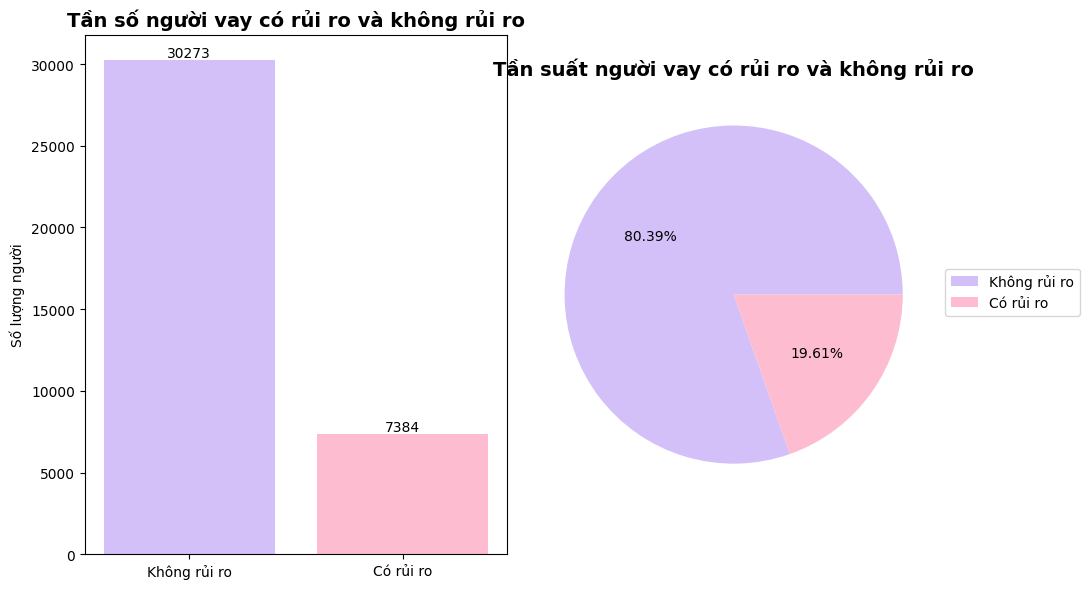

Đã lưu biểu đồ: images\analysis\Tần suất người vay có rủi ro và không rủi ro.png


,so_luong,ty_le_%
Risk Flag,,
0,30273,80.39
1,7384,19.61


In [ ]:
risk_counts = df["Risk Flag"].value_counts().reindex([0, 1], fill_value=0)
risk_percentages = risk_counts / risk_counts.sum() * 100
risk_names = [RISK_LABELS[value] for value in risk_counts.index]

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(11, 6))
ax_bar.bar(risk_names, risk_counts.values, color=TWO_COLOR_PALETTE)
ax_bar.set_ylabel("Số lượng người")
ax_bar.set_title("Tần số người vay có rủi ro và không rủi ro", fontweight="bold", fontsize=14)
add_bar_labels(ax_bar)

ax_pie.pie(risk_percentages, autopct="%.2f%%", colors=TWO_COLOR_PALETTE)
ax_pie.legend(risk_names, loc=(1, 0.45))
ax_pie.set_title("Tần suất người vay có rủi ro và không rủi ro", fontweight="bold", fontsize=14)

saved_path = save_chart("Tần suất người vay có rủi ro và không rủi ro.png")
plt.show()
print(f"Đã lưu biểu đồ: {saved_path}")

display(pd.DataFrame({"so_luong": risk_counts, "ty_le_%": risk_percentages.round(2)}))

### Tóm tắt phân bố nhãn rủi ro

- Phần tần số cho biết số lượng tuyệt đối ở từng nhóm.
- Phần tần suất giúp so sánh tỷ trọng, đặc biệt hữu ích nếu dữ liệu bị lệch nhãn.


## 6. Mô tả nhóm khách hàng có rủi ro theo biến số

Ba biến `Income`, `Age`, `Experience` được mô tả bằng min, max, mean, median, mode xấp xỉ và các phân vị.


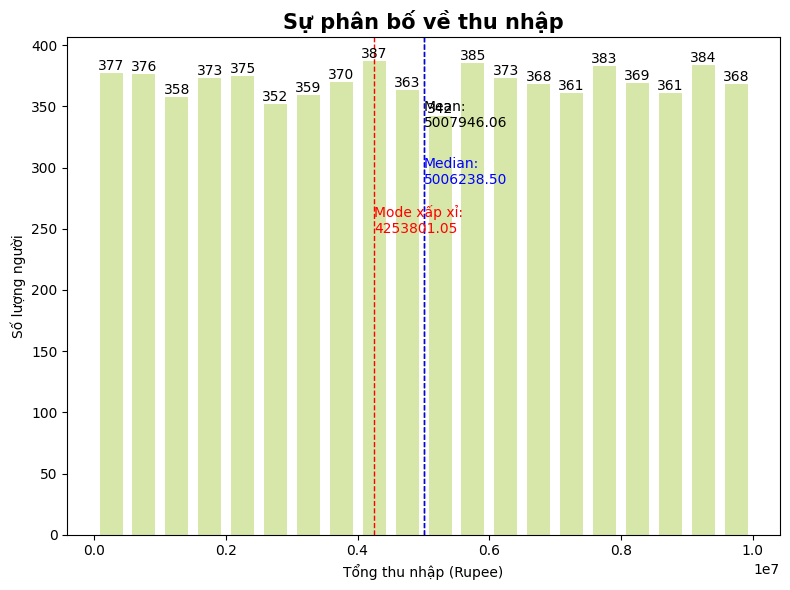

Đã lưu biểu đồ: images\analysis\Sự phân bố về thu nhập.png


,income
min,1.067500e+04
max,9.994501e+06
mean,5.007946e+06
median,5.006238e+06
mode_xap_xi,4.253801e+06
q25,2.492112e+06
q50,5.006238e+06
q75,7.529021e+06


In [ ]:
income_stats = plot_numeric_distribution(
    risky_df["Income"],
    bins=20,
    xlabel="Tổng thu nhập (Rupee)",
    title="Sự phân bố về thu nhập",
    filename="Sự phân bố về thu nhập.png",
)
display(income_stats.to_frame("income"))

### Tóm tắt thu nhập

- Histogram cho thấy mức thu nhập của nhóm khách hàng rủi ro tập trung ở những khoảng nào.
- Mean, median và mode xấp xỉ được vẽ trực tiếp để dễ so sánh độ lệch của phân phối.


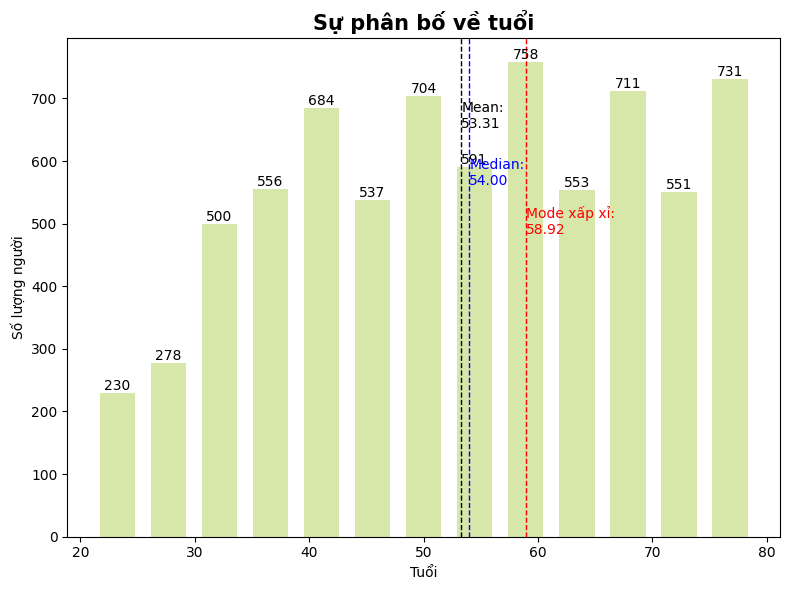

Đã lưu biểu đồ: images\analysis\Sự phân bố về tuổi.png


,age
min,21.000000
max,79.000000
mean,53.307828
median,54.000000
mode_xap_xi,58.923077
q25,40.000000
q50,54.000000
q75,66.000000


In [ ]:
age_stats = plot_numeric_distribution(
    risky_df["Age"],
    bins=13,
    xlabel="Tuổi",
    title="Sự phân bố về tuổi",
    filename="Sự phân bố về tuổi.png",
)
display(age_stats.to_frame("age"))

### Tóm tắt tuổi

- Phân phối tuổi giúp nhận diện nhóm tuổi xuất hiện nhiều trong tập khách hàng rủi ro.
- Các phân vị hỗ trợ đọc nhanh khoảng tuổi trung tâm thay vì chỉ nhìn giá trị trung bình.


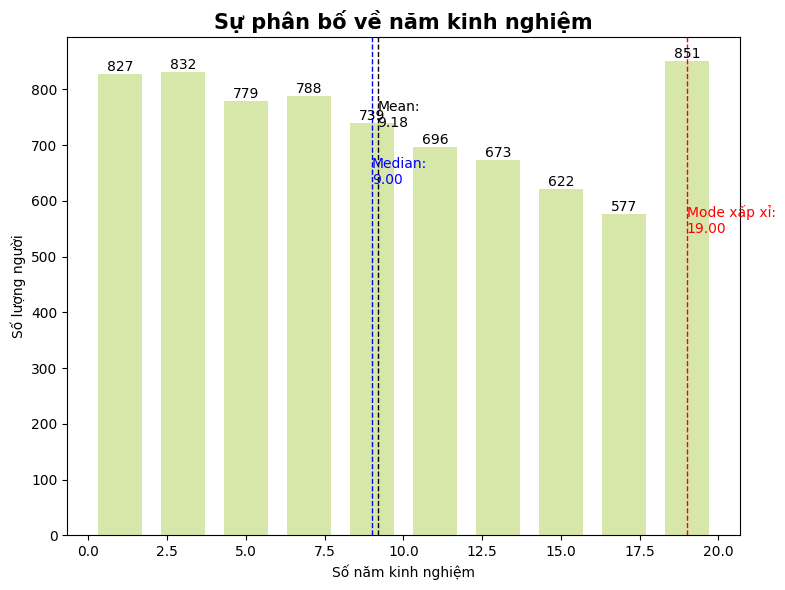

Đã lưu biểu đồ: images\analysis\Sự phân bố về năm kinh nghiệm.png


,experience
min,0.00000
max,20.00000
mean,9.18039
median,9.00000
mode_xap_xi,19.00000
q25,4.00000
q50,9.00000
q75,14.00000


In [ ]:
experience_stats = plot_numeric_distribution(
    risky_df["Experience"],
    bins=10,
    xlabel="Số năm kinh nghiệm",
    title="Sự phân bố về năm kinh nghiệm",
    filename="Sự phân bố về năm kinh nghiệm.png",
)
display(experience_stats.to_frame("experience"))

### Tóm tắt kinh nghiệm

- Biểu đồ kinh nghiệm cho biết nhóm rủi ro phân bố ra sao theo số năm làm việc.
- Điều kiện làm sạch ở notebook trước đã loại các dòng có kinh nghiệm không hợp lý so với tuổi.


## 7. Mô tả nhóm khách hàng có rủi ro theo biến phân loại

Các biến phân loại được tính động bằng `value_counts()` để tránh sai số do hard-code số lượng.


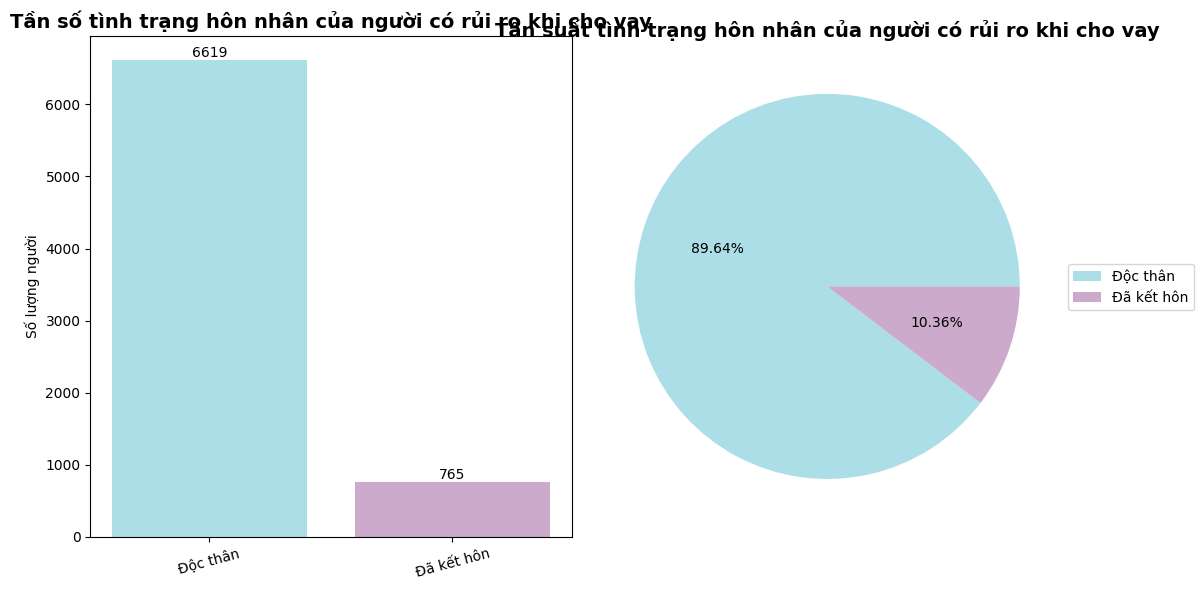

Đã lưu biểu đồ: images\analysis\Tình trạng hôn nhân.png


,so_luong,ty_le_%
Married/Single,,
single,6619,89.64
married,765,10.36


In [ ]:
marital_summary = plot_category_distribution(
    risky_df["Married/Single"],
    order=["single", "married"],
    labels={"single": "Độc thân", "married": "Đã kết hôn"},
    title="tình trạng hôn nhân của người có rủi ro khi cho vay",
    filename="Tình trạng hôn nhân.png",
)
display(marital_summary)

### Tóm tắt tình trạng hôn nhân

- Bảng và biểu đồ dùng cùng một nguồn đếm nên tránh lệch giữa số liệu in ra và hình ảnh.
- Nhãn tiếng Việt chỉ dùng để trình bày, dữ liệu gốc vẫn giữ mã phân loại đã chuẩn hóa.


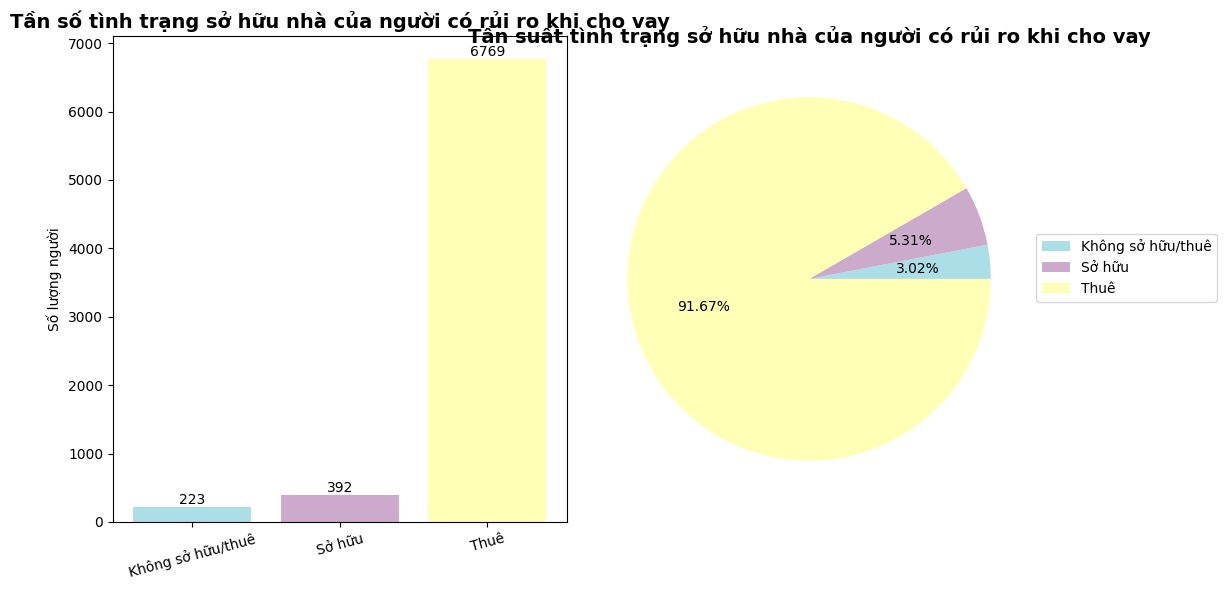

Đã lưu biểu đồ: images\analysis\Tình trạng sở hữu nhà.png


,so_luong,ty_le_%
House Ownership,,
norent noown,223,3.02
owned,392,5.31
rented,6769,91.67


In [ ]:
house_summary = plot_category_distribution(
    risky_df["House Ownership"],
    order=["norent noown", "owned", "rented"],
    labels={"norent noown": "Không sở hữu/thuê", "owned": "Sở hữu", "rented": "Thuê"},
    title="tình trạng sở hữu nhà của người có rủi ro khi cho vay",
    filename="Tình trạng sở hữu nhà.png",
)
display(house_summary)

### Tóm tắt sở hữu nhà

- Phân tích này so sánh ba nhóm: không sở hữu/không thuê, sở hữu và thuê nhà.
- Việc đặt `order` cố định giúp thứ tự cột ổn định giữa các lần chạy notebook.


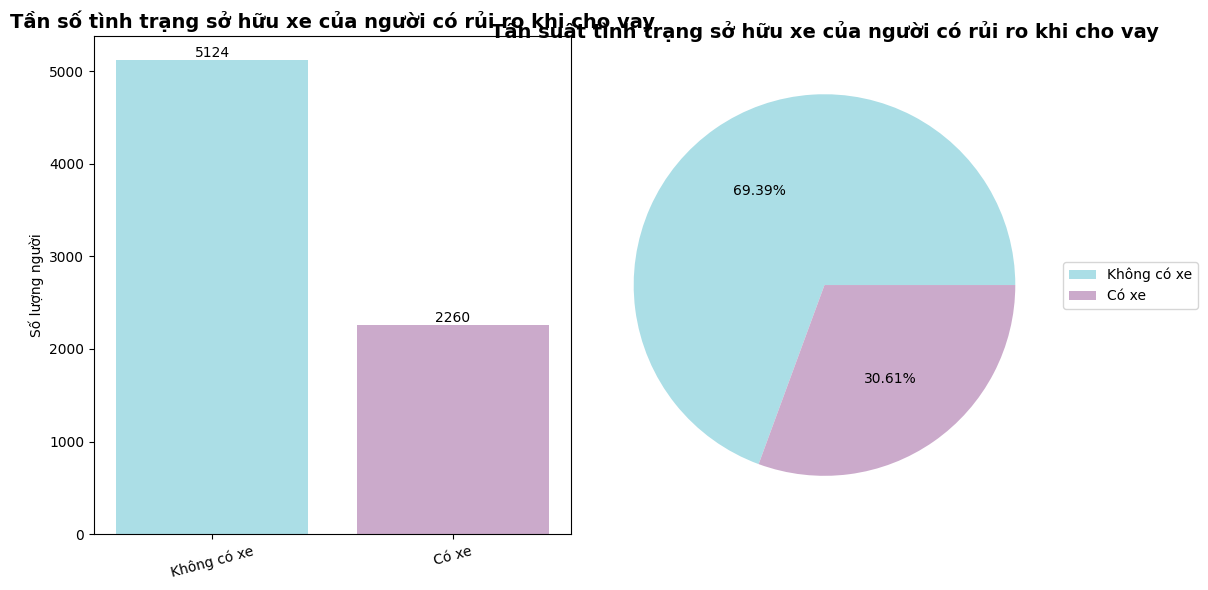

Đã lưu biểu đồ: images\analysis\Tình trạng sở hữu xe.png


,so_luong,ty_le_%
Car Ownership,,
no,5124,69.39
yes,2260,30.61


In [ ]:
car_summary = plot_category_distribution(
    risky_df["Car Ownership"],
    order=["no", "yes"],
    labels={"no": "Không có xe", "yes": "Có xe"},
    title="tình trạng sở hữu xe của người có rủi ro khi cho vay",
    filename="Tình trạng sở hữu xe.png",
)
display(car_summary)

### Tóm tắt sở hữu xe

- Biến sở hữu xe được giữ ở dạng nhị phân `no/yes` trong dữ liệu và chuyển sang tiếng Việt khi hiển thị.
- Biểu đồ cột và tròn giúp đọc cả số lượng lẫn tỷ trọng của từng nhóm.


## 8. Top nghề nghiệp và nơi cư trú của nhóm khách hàng rủi ro

Hai phần này trước đây dùng danh sách hard-code; hiện tại được tính trực tiếp từ dữ liệu để tự cập nhật nếu CSV thay đổi.


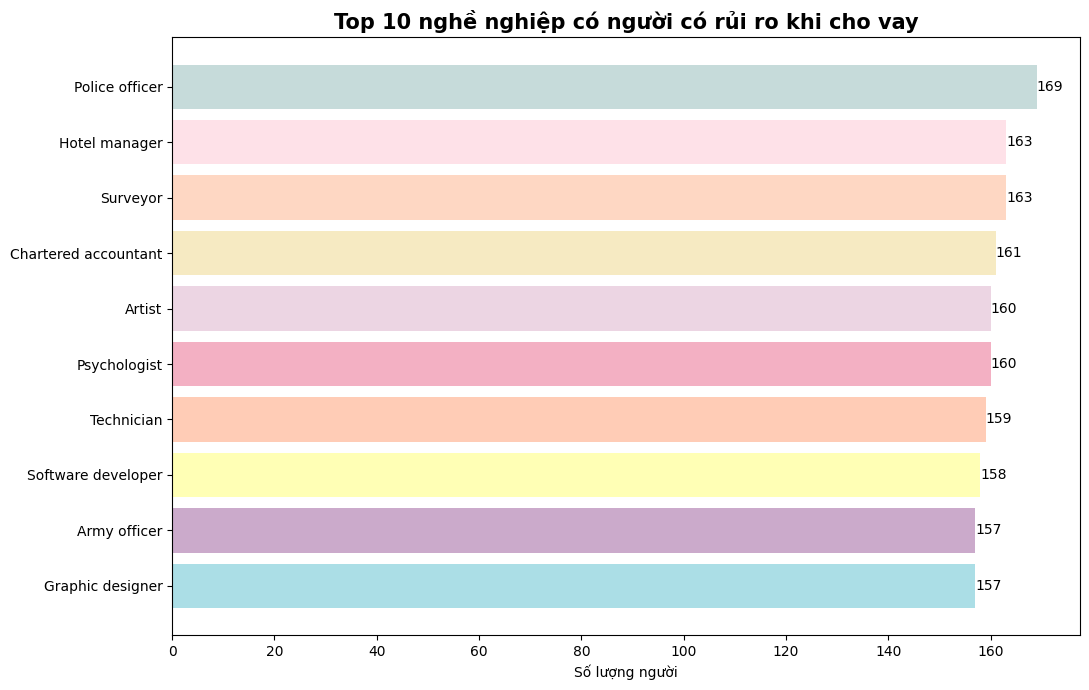

Đã lưu biểu đồ: images\analysis\Top 10 nghề nghiệp có người có rủi ro khi cho vay.png


,so_luong
Profession,
Police officer,169
Surveyor,163
Hotel manager,163
Chartered accountant,161
Psychologist,160
Artist,160
Technician,159
Software developer,158
Army officer,157


In [ ]:
profession_counts = risky_df["Profession"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(profession_counts.index, profession_counts.values, color=MULTI_COLOR_PALETTE[: len(profession_counts)])
ax.set_xlabel("Số lượng người")
ax.set_title("Top 10 nghề nghiệp có người có rủi ro khi cho vay", fontweight="bold", fontsize=15)
add_bar_labels(ax)

saved_path = save_chart("Top 10 nghề nghiệp có người có rủi ro khi cho vay.png")
plt.show()
print(f"Đã lưu biểu đồ: {saved_path}")

display(profession_counts.sort_values(ascending=False).to_frame("so_luong"))

### Tóm tắt nghề nghiệp

- Top 10 nghề nghiệp được lấy bằng `value_counts().head(10)`, không còn phụ thuộc vào danh sách nhập tay.
- Biểu đồ thanh ngang giúp tên nghề dài dễ đọc hơn so với biểu đồ cột xoay nhãn.


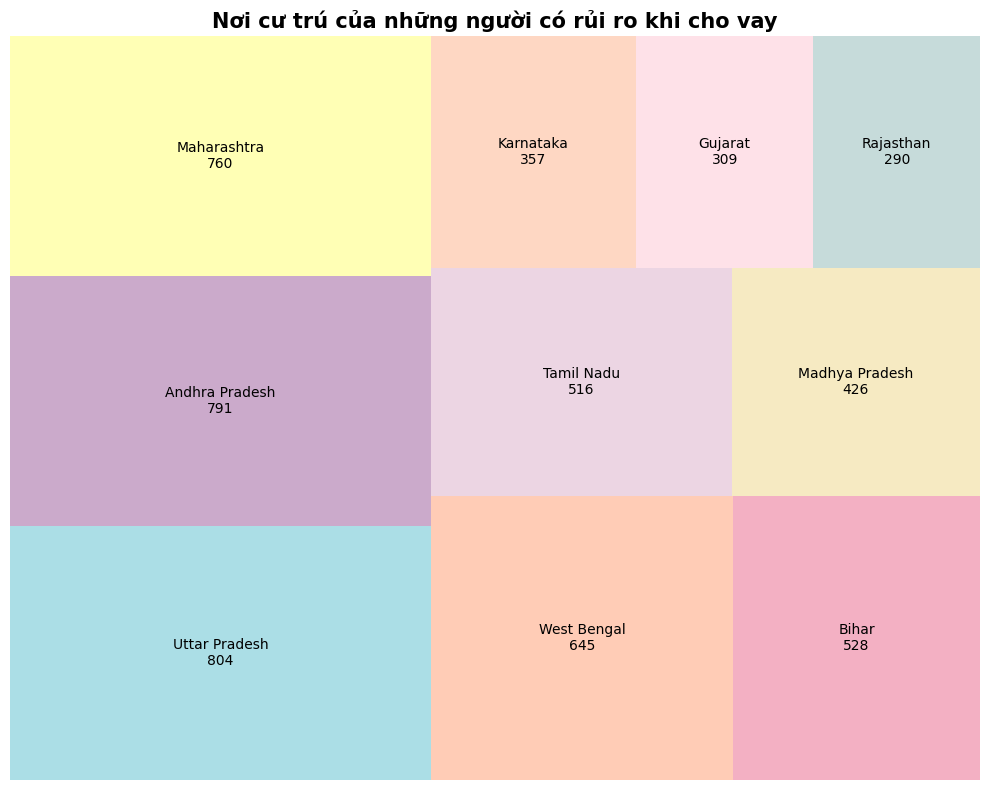

Đã lưu biểu đồ: images\analysis\Nơi cư trú của những người có rủi ro khi cho vay.png


,so_luong
State,
Uttar Pradesh,804
Andhra Pradesh,791
Maharashtra,760
West Bengal,645
Bihar,528
Tamil Nadu,516
Madhya Pradesh,426
Karnataka,357
Gujarat,309


In [ ]:
state_counts = risky_df["State"].value_counts().head(10)
state_labels = [f"{state}\n{count}" for state, count in state_counts.items()]

fig, ax = plt.subplots(figsize=(10, 8))
squarify.plot(
    sizes=state_counts.values,
    label=state_labels,
    color=MULTI_COLOR_PALETTE[: len(state_counts)],
    ax=ax,
    text_kwargs={"fontsize": 10},
)
ax.axis("off")
ax.set_title("Nơi cư trú của những người có rủi ro khi cho vay", fontweight="bold", fontsize=15)

saved_path = save_chart("Nơi cư trú của những người có rủi ro khi cho vay.png")
plt.show()
print(f"Đã lưu biểu đồ: {saved_path}")

display(state_counts.to_frame("so_luong"))

### Tóm tắt nơi cư trú

- Treemap hiển thị 10 bang/vùng lãnh thổ có nhiều khách hàng rủi ro nhất.
- Nhãn trên từng ô được tạo từ dữ liệu thật, nên số lượng không bị lệch khi notebook chạy lại.


## Tóm tắt toàn notebook

- Dữ liệu phân tích được lấy từ `data/data_valid.csv` sau bước làm sạch.
- Các biểu đồ được lưu tự động vào `images/analysis/`.
- Những phần từng hard-code số lượng nghề nghiệp và nơi cư trú đã được thay bằng thống kê động.
- Mỗi nhóm phân tích đều có phần comment trong code và summary tiếng Việt để dễ theo dõi lại quy trình.
